# Implementing a Sentence Transformer Model

03/31/2025

This notebook created for the technical assessment for Fetch, a rewards point service.

This notebook performs exploratory data analysis on a few datasets made available through Huggingface and other sources. The idea is to explore these datasets before they get used in the other notebooks for similarity search and named entity recognition.

The documentation for this library may be found here: https://www.sbert.net/

# Step 1: Implement a Sentence Transformer Model

I am going to install a number of natural language processing libraries, in order to perform preliminary Exploratory Data Analysis to find datasets that would be good to explore for classification and named entity recognition.

In [1]:
!pip install -U sentence-transformers
!pip install datasets
!pip install transformers
!pip install evaluate
!pip install seqeval

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 340.6/340.6 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 48.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalli

In [2]:
import numpy as np
import pandas as pd
from datasets import load_dataset, DatasetDict
import nltk
from nltk.tokenize import PunktTokenizer
import seaborn


In [3]:
# Importing "IMDb" dataset from Huggingface
imdb_ds = load_dataset("imdb")

# Initialize the NLTK Sentence Tokenizer
nltk.download('punkt_tab')
sentence_tokenizer = PunktTokenizer()

# Display the structure of the dataset
print(imdb_ds)

# Display the 'training' split of the dataset
print(imdb_ds["train"])


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

unsupervised-00000-of-00001.parquet:   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})
Dataset({
    features: ['text', 'label'],
    num_rows: 25000
})


In [4]:
# I convert each dataset subset into pandas DataFrames
# This includes the 'train' subset for training, 'test' subset for testing, and the 'unsupervised' subset in order to find out what it is for.
imdb_train_ds = imdb_ds["train"].to_pandas()
imdb_test_ds = imdb_ds["test"].to_pandas()
imdb_unsupervised_ds = imdb_ds["unsupervised"].to_pandas()


I want to perform a few different explorations on the data.
- To find out how many "labels" there are per dataset.
- I want to find out the distribution of how many samples there are for each label.
- I want to find out how many sentences there are in each 'text.' For this, I will use the Punkt sentence tokenizer from NLTK. https://www.nltk.org/api/nltk.tokenize.punkt.html

In [5]:
imdb_train_ds.head(10)

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0
5,I would put this at the top of my list of film...,0
6,Whoever wrote the screenplay for this movie ob...,0
7,"When I first saw a glimpse of this movie, I qu...",0
8,"Who are these ""They""- the actors? the filmmake...",0
9,This is said to be a personal film for Peter B...,0


In [6]:
imdb_train_ds['label'].unique()

array([0, 1])

                                                text  label  \
0  I rented I AM CURIOUS-YELLOW from my video sto...      0   
1  "I Am Curious: Yellow" is a risible and preten...      0   
2  If only to avoid making this type of film in t...      0   
3  This film was probably inspired by Godard's Ma...      0   
4  Oh, brother...after hearing about this ridicul...      0   

                                     split_sentences  num_sentences  
0  [I rented I AM CURIOUS-YELLOW from my video st...              9  
1  ["I Am Curious: Yellow" is a risible and prete...             11  
2  [If only to avoid making this type of film in ...              3  
3  [This film was probably inspired by Godard's M...              7  
4  [Oh, brother...after hearing about this ridicu...              6  
                                                text  \
0  I rented I AM CURIOUS-YELLOW from my video sto...   
1  "I Am Curious: Yellow" is a risible and preten...   
2  If only to avoid making this t

<Axes: xlabel='label', ylabel='num_sentences'>

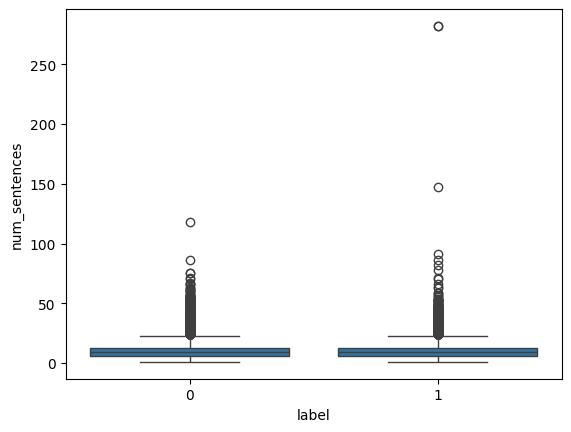

In [14]:
tokenized_sentences_results = []
num_sentences = 0

for entry in imdb_train_ds['text']:
  result_tokens = sentence_tokenizer.tokenize(entry)
  num_sentences = len(result_tokens)
  tokenized_sentences_results.append([result_tokens, num_sentences])

tokenized_sentences_train_ds = pd.DataFrame(data=tokenized_sentences_results, columns=["split_sentences", "num_sentences"])

imdb_train_ds_with_sentences = imdb_train_ds.join(tokenized_sentences_train_ds, how="outer")

print(imdb_train_ds_with_sentences.head())

# I take a moment to reorganize the column order of the dataframe, so that label is the final column.
imdb_train_ds_with_sentences = imdb_train_ds_with_sentences.reindex(columns=['text', 'split_sentences', 'num_sentences', 'label'])
print(imdb_train_ds_with_sentences.head())

# I will join this pandas dataframe with the originating train dataframe
#print(imdb_train_ds_with_sentence_tokens.head())
#seaborn.displot(imdb_train_ds_with_sentence_tokens, x="num_sentences", binwidth=20)

seaborn.boxplot(imdb_train_ds_with_sentences, x="label", y="num_sentences")

Based on the above plot, I will split the data into two subsets. One that has reviews that are shorter than a certain threshold of sentences, and one that has reviews longer than a certain threshold of sentences. The threshold could be 50.

<Axes: xlabel='label', ylabel='num_sentences'>

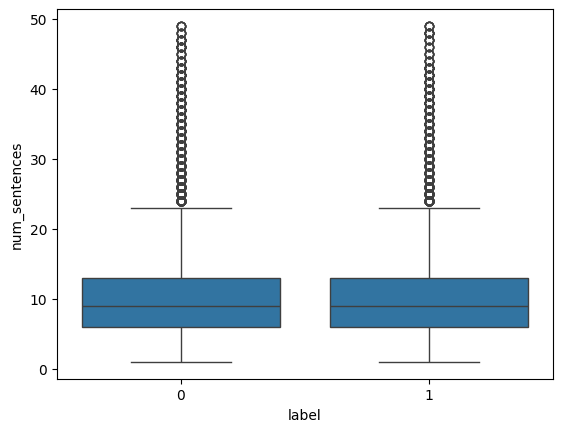

In [16]:
boolean_mask = imdb_train_ds_with_sentences["num_sentences"] < 50
less_than_50_sentences_imdb_train_ds = imdb_train_ds_with_sentences[boolean_mask]

seaborn.boxplot(less_than_50_sentences_imdb_train_ds, x="label", y="num_sentences")

<Axes: xlabel='label', ylabel='num_sentences'>

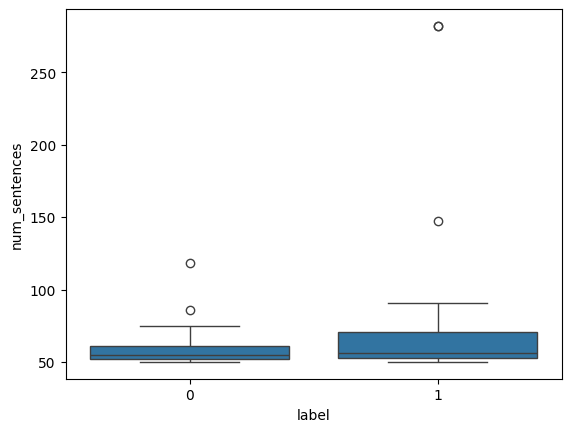

In [18]:
greater_than_50_sentences_imdb_train_ds = imdb_train_ds_with_sentences[~boolean_mask]

seaborn.boxplot(greater_than_50_sentences_imdb_train_ds, x="label", y="num_sentences")

In [19]:
imdb_test_ds.head(10)

,text,label
0,I love sci-fi and am willing to put up with a ...,0
1,"Worth the entertainment value of a rental, esp...",0
2,its a totally average film with a few semi-alr...,0
3,STAR RATING: ***** Saturday Night **** Friday ...,0
4,"First off let me say, If you haven't enjoyed a...",0
5,I had high hopes for this one until they chang...,0
6,Isaac Florentine has made some of the best wes...,0
7,"It actually pains me to say it, but this movie...",0
8,"Technically I'am a Van Damme Fan, or I was. th...",0
9,"Honestly awful film, bad editing, awful lighti...",0


In [20]:
imdb_test_ds['label'].unique()

array([0, 1])

                                                text  label  \
0  I love sci-fi and am willing to put up with a ...      0   
1  Worth the entertainment value of a rental, esp...      0   
2  its a totally average film with a few semi-alr...      0   
3  STAR RATING: ***** Saturday Night **** Friday ...      0   
4  First off let me say, If you haven't enjoyed a...      0   

                                     split_sentences  num_sentences  
0  [I love sci-fi and am willing to put up with a...             19  
1  [Worth the entertainment value of a rental, es...             11  
2  [its a totally average film with a few semi-al...              5  
3  [STAR RATING: ***** Saturday Night **** Friday...             11  
4  [First off let me say, If you haven't enjoyed ...              7  
                                                text  \
0  I love sci-fi and am willing to put up with a ...   
1  Worth the entertainment value of a rental, esp...   
2  its a totally average film wit

<Axes: xlabel='label', ylabel='num_sentences'>

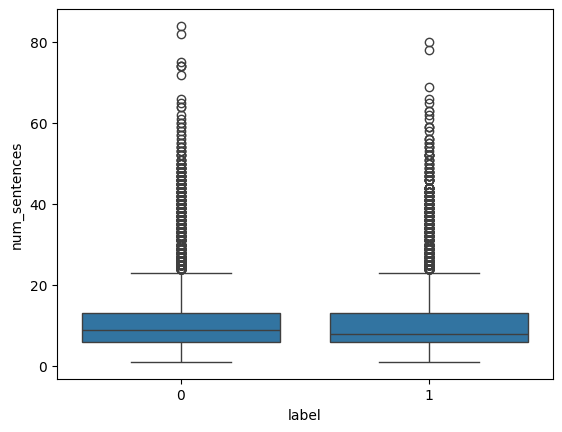

In [22]:
tokenized_sentences_results = []
num_sentences = 0

for entry in imdb_test_ds['text']:
  result_tokens = sentence_tokenizer.tokenize(entry)
  num_sentences = len(result_tokens)
  tokenized_sentences_results.append([result_tokens, num_sentences])

tokenized_sentences_test_df = pd.DataFrame(data=tokenized_sentences_results, columns=["split_sentences", "num_sentences"])

imdb_test_ds_with_sentences = imdb_test_ds.join(tokenized_sentences_test_df, how="outer")

print(imdb_test_ds_with_sentences.head())

# I take a moment to reorganize the column order of the dataframe, so that label is the final column.
imdb_test_ds_with_sentences = imdb_test_ds_with_sentences.reindex(columns=['text', 'split_sentences', 'num_sentences', 'label'])
print(imdb_test_ds_with_sentences.head())

# I will join this pandas dataframe with the originating train dataframe
#print(imdb_test_ds_with_sentences.head())
#seaborn.displot(imdb_test_ds_with_sentences, x="num_sentences", binwidth=20)

print(imdb_test_ds_with_sentences.head())
seaborn.boxplot(imdb_test_ds_with_sentences, x="label", y="num_sentences")

# seaborn.displot(imdb_test_ds_with_sentences, x="num_sentences", binwidth=20)
# seaborn.boxplot(imdb_test_ds_with_sentences, x="label", y="num_sentences")

In [23]:
imdb_unsupervised_ds.head()

,text,label
0,This is just a precious little diamond. The pl...,-1
1,When I say this is my favourite film of all ti...,-1
2,I saw this movie because I am a huge fan of th...,-1
3,Being that the only foreign films I usually li...,-1
4,After seeing Point of No Return (a great movie...,-1


In [26]:
imdb_unsupervised_ds['label'].unique()

array([-1])

                                                text  label  \
0  This is just a precious little diamond. The pl...     -1   
1  When I say this is my favourite film of all ti...     -1   
2  I saw this movie because I am a huge fan of th...     -1   
3  Being that the only foreign films I usually li...     -1   
4  After seeing Point of No Return (a great movie...     -1   

                                     split_sentences  num_sentences  
0  [This is just a precious little diamond., The ...             14  
1  [When I say this is my favourite film of all t...             11  
2  [I saw this movie because I am a huge fan of t...              4  
3  [Being that the only foreign films I usually l...              4  
4  [After seeing Point of No Return (a great movi...              6  
                                                text  \
0  This is just a precious little diamond. The pl...   
1  When I say this is my favourite film of all ti...   
2  I saw this movie because I am 

<Axes: xlabel='label', ylabel='num_sentences'>

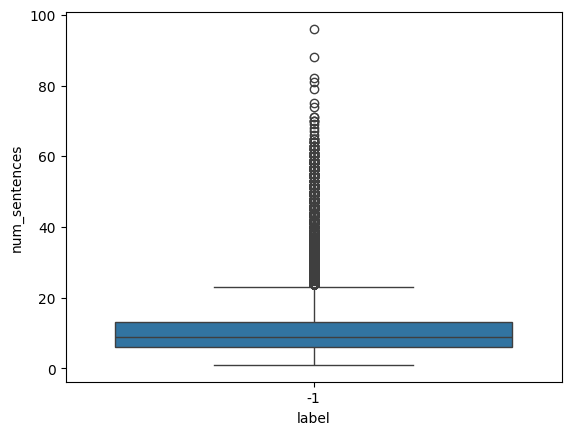

In [25]:
tokenized_sentences_results = []
num_sentences = 0

for entry in imdb_unsupervised_ds['text']:
  result_tokens = sentence_tokenizer.tokenize(entry)
  num_sentences = len(result_tokens)
  tokenized_sentences_results.append([result_tokens, num_sentences])

tokenized_sentences_unsupervised_df = pd.DataFrame(data=tokenized_sentences_results, columns=["split_sentences", "num_sentences"])

imdb_unsupervised_ds_with_sentences = imdb_unsupervised_ds.join(tokenized_sentences_unsupervised_df, how="outer")

print(imdb_unsupervised_ds_with_sentences.head())
imdb_unsupervised_ds_with_sentences = imdb_unsupervised_ds_with_sentences.reindex(columns=['text', 'split_sentences', 'num_sentences', 'label'])

print(imdb_unsupervised_ds_with_sentences.head())
# seaborn.displot(imdb_unsupervised_ds_with_sentences, x="num_sentences", binwidth=20)
seaborn.boxplot(imdb_unsupervised_ds_with_sentences, x="label", y="num_sentences")